**1. Import Libraries**

In [48]:
# Basic libraries for data work
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

2. Load Dataset

In [49]:
df = pd.read_csv('/content/lung_cancer_data.csv')
# Show first few rows
df.head()

,Patient_ID,Age,Gender,Smoking_History,Tumor_Size_mm,Tumor_Location,Stage,Treatment,Survival_Months,Ethnicity,...,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
0,Patient0000,68,Male,Current Smoker,81.678677,Lower Lobe,Stage III,Surgery,44,Hispanic,...,27.985571,46.801214,1.245849,239.240255,10.366307,3.547734,113.919243,4.968163,139.822861,17.006956
1,Patient0001,58,Male,Never Smoked,78.448272,Lower Lobe,Stage I,Radiation Therapy,101,Caucasian,...,30.120956,39.711531,1.463231,233.515237,10.081731,2.945020,101.321578,3.896795,135.449361,93.270893
2,Patient0002,44,Male,Former Smoker,67.714305,Lower Lobe,Stage I,Chemotherapy,69,African American,...,5.882418,32.640602,0.630109,169.037460,8.660892,4.637399,78.214177,4.369050,143.377155,70.348376
3,Patient0003,72,Male,Current Smoker,70.806008,Lower Lobe,Stage III,Chemotherapy,95,African American,...,38.908154,44.319393,0.594342,213.967590,8.832669,3.617098,127.895361,4.348474,138.586005,19.828128
4,Patient0004,37,Female,Never Smoked,87.272433,Lower Lobe,Stage IV,Radiation Therapy,105,Asian,...,26.344877,15.746906,1.478239,118.187543,9.247609,4.773255,148.801185,3.671976,141.230724,81.047456


3. Basic Data Understanding

In [50]:
# Check number of rows and columns
df.shape

(23658, 38)

In [51]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23658 entries, 0 to 23657
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        23658 non-null  object 
 1   Age                               23658 non-null  int64  
 2   Gender                            23658 non-null  object 
 3   Smoking_History                   23658 non-null  object 
 4   Tumor_Size_mm                     23658 non-null  float64
 5   Tumor_Location                    23658 non-null  object 
 6   Stage                             23658 non-null  object 
 7   Treatment                         23658 non-null  object 
 8   Survival_Months                   23658 non-null  int64  
 9   Ethnicity                         23658 non-null  object 
 10  Insurance_Type                    23658 non-null  object 
 11  Family_History                    23658 non-null  object 
 12  Como

In [52]:
# Basic statistics for numeric columns
df.describe()

,Age,Tumor_Size_mm,Survival_Months,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,...,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
count,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,...,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000
mean,54.439344,55.383736,59.863809,1.999915,134.462381,84.475780,79.585299,14.000137,6.735637,299.867482,...,22.504677,30.133226,0.999459,174.734575,9.261114,3.742771,109.895553,4.245646,140.028215,49.913594
std,14.396386,26.004354,34.246042,1.413675,26.020492,14.409826,11.546690,2.301411,1.879292,86.897568,...,10.047864,11.560915,0.287517,43.230997,0.719875,0.721708,23.109136,0.431968,2.894568,28.870940
min,30.000000,10.004279,1.000000,0.000000,90.000000,60.000000,60.000000,10.000070,3.501213,150.017892,...,5.001090,10.000860,0.500001,100.002721,8.000018,2.500069,70.000420,3.500034,135.000934,0.016800
25%,42.000000,32.972797,30.000000,1.000000,112.000000,72.000000,70.000000,11.990625,5.108723,224.884576,...,13.816180,20.065339,0.748845,137.444977,8.640877,3.120107,89.828616,3.871842,137.540078,25.026793
50%,54.000000,55.296297,60.000000,2.000000,134.000000,85.000000,80.000000,13.983383,6.729774,299.933443,...,22.547943,30.271772,1.001183,174.390634,9.259304,3.730837,109.949488,4.242236,140.002209,49.926220
75%,67.000000,78.190014,89.000000,3.000000,157.000000,97.000000,90.000000,15.999260,8.353701,375.437029,...,31.092935,40.107488,1.249173,212.228273,9.883248,4.364422,130.061977,4.618318,142.541883,74.924580
max,79.000000,99.990554,119.000000,4.000000,179.000000,109.000000,99.000000,17.999957,9.999535,449.974734,...,39.999543,49.998571,1.499998,249.996391,10.499913,4.999974,149.997056,4.999954,144.999869,99.999493


In [53]:
# Basic statistics for numeric columns
df.describe()

,Age,Tumor_Size_mm,Survival_Months,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,...,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
count,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,...,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000
mean,54.439344,55.383736,59.863809,1.999915,134.462381,84.475780,79.585299,14.000137,6.735637,299.867482,...,22.504677,30.133226,0.999459,174.734575,9.261114,3.742771,109.895553,4.245646,140.028215,49.913594
std,14.396386,26.004354,34.246042,1.413675,26.020492,14.409826,11.546690,2.301411,1.879292,86.897568,...,10.047864,11.560915,0.287517,43.230997,0.719875,0.721708,23.109136,0.431968,2.894568,28.870940
min,30.000000,10.004279,1.000000,0.000000,90.000000,60.000000,60.000000,10.000070,3.501213,150.017892,...,5.001090,10.000860,0.500001,100.002721,8.000018,2.500069,70.000420,3.500034,135.000934,0.016800
25%,42.000000,32.972797,30.000000,1.000000,112.000000,72.000000,70.000000,11.990625,5.108723,224.884576,...,13.816180,20.065339,0.748845,137.444977,8.640877,3.120107,89.828616,3.871842,137.540078,25.026793
50%,54.000000,55.296297,60.000000,2.000000,134.000000,85.000000,80.000000,13.983383,6.729774,299.933443,...,22.547943,30.271772,1.001183,174.390634,9.259304,3.730837,109.949488,4.242236,140.002209,49.926220
75%,67.000000,78.190014,89.000000,3.000000,157.000000,97.000000,90.000000,15.999260,8.353701,375.437029,...,31.092935,40.107488,1.249173,212.228273,9.883248,4.364422,130.061977,4.618318,142.541883,74.924580
max,79.000000,99.990554,119.000000,4.000000,179.000000,109.000000,99.000000,17.999957,9.999535,449.974734,...,39.999543,49.998571,1.499998,249.996391,10.499913,4.999974,149.997056,4.999954,144.999869,99.999493


In [54]:
# Check missing values
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Smoking_History,0
Tumor_Size_mm,0
Tumor_Location,0
Stage,0
Treatment,0
Survival_Months,0
Ethnicity,0


4. Data Cleaning

In [55]:
# Remove duplicate rows if any
df = df.drop_duplicates()

# Check new shape after removing duplicates
df.shape

(23658, 38)

In [56]:
# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [57]:
# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [58]:
# Clean extra spaces in text columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

5. Feature Engineering

`Create Stage Number`

In [59]:
# Convert cancer stage into numeric order
stage_map = {
    'Stage I': 1,
    'Stage II': 2,
    'Stage III': 3,
    'Stage IV': 4
}

df['Stage_Num'] = df['Stage'].map(stage_map)

`Create Age Group`

In [60]:
# Create age groups for cohort analysis
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 40, 55, 70, 100],
    labels=['Young', 'Middle Age', 'Senior', 'Elder']
)

`Create Comorbidity Count`

In [61]:
# List of comorbidity columns
comorbidity_cols = [
    'Comorbidity_Diabetes',
    'Comorbidity_Hypertension',
    'Comorbidity_Heart_Disease',
    'Comorbidity_Chronic_Lung_Disease',
    'Comorbidity_Kidney_Disease',
    'Comorbidity_Autoimmune_Disease',
    'Comorbidity_Other'
]

# Count how many conditions each patient has
df['Comorbidity_Count'] = (df[comorbidity_cols] == 'Yes').sum(axis=1)

`Create High Risk Target`

In [62]:
# We define high risk as survival below 60 months
# This is a proxy target because the dataset does not have real death/follow-up status
df['High_Risk'] = (df['Survival_Months'] < 60).astype(int)

# Check distribution
df['High_Risk'].value_counts()

,count
High_Risk,
0,11948
1,11710


6. Exploratory Data Analysis

`Survival by Stage`

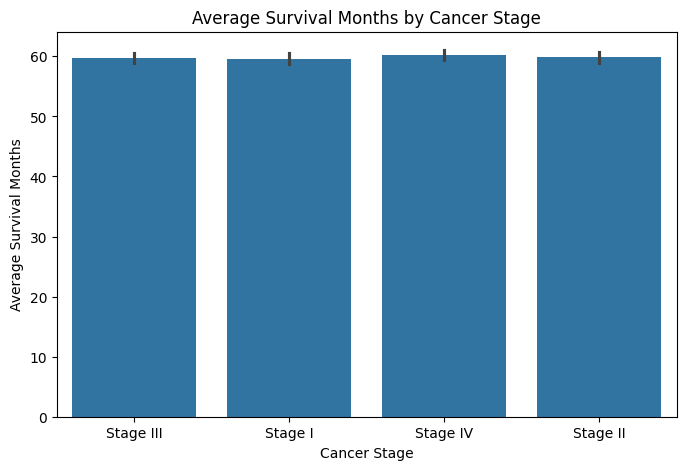

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Stage', y='Survival_Months')
plt.title('Average Survival Months by Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Average Survival Months')
plt.show()

`Survival by Smoking History`

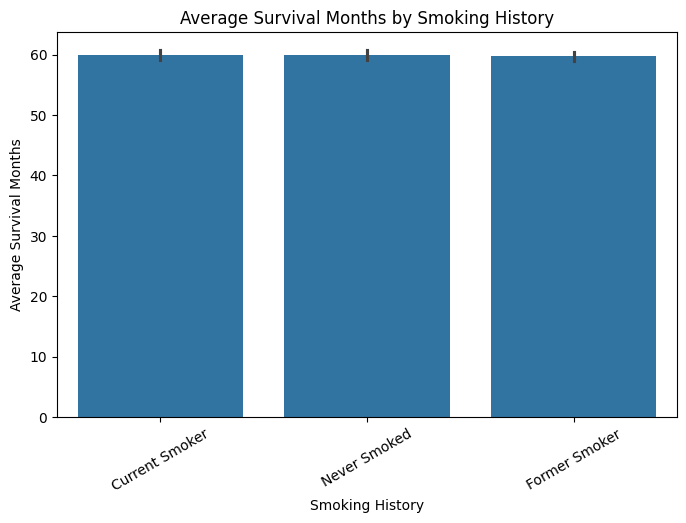

In [64]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Smoking_History', y='Survival_Months')
plt.title('Average Survival Months by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Average Survival Months')
plt.xticks(rotation=30)
plt.show()

`Survival by Treatment`

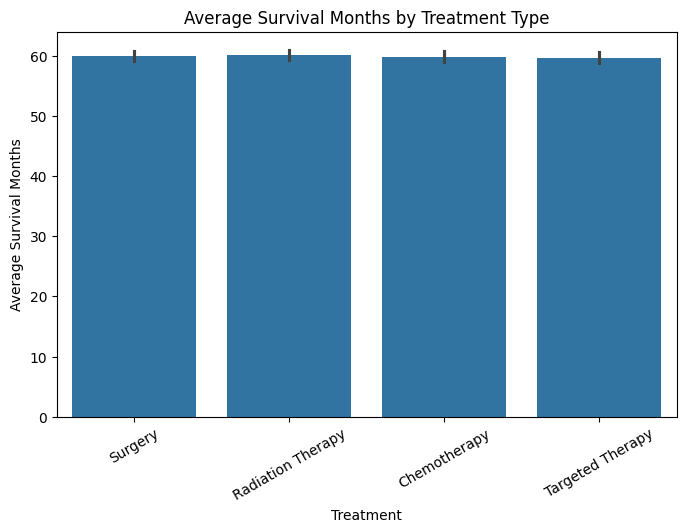

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Treatment', y='Survival_Months')
plt.title('Average Survival Months by Treatment Type')
plt.xlabel('Treatment')
plt.ylabel('Average Survival Months')
plt.xticks(rotation=30)
plt.show()

`Comorbidity Count vs Survival`

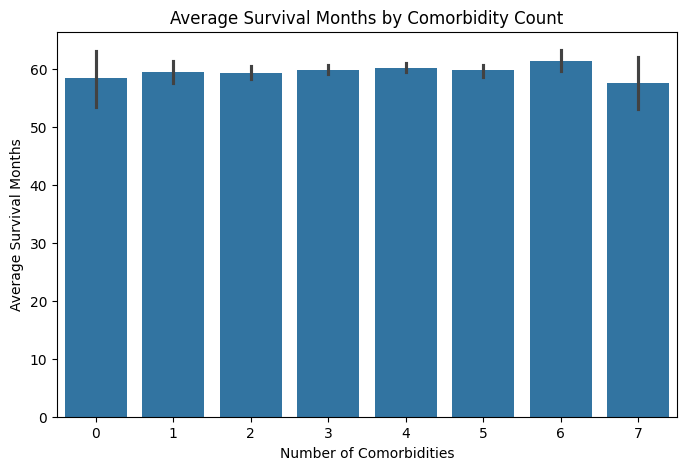

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Comorbidity_Count', y='Survival_Months')
plt.title('Average Survival Months by Comorbidity Count')
plt.xlabel('Number of Comorbidities')
plt.ylabel('Average Survival Months')
plt.show()

`Tumor Size Distribution`

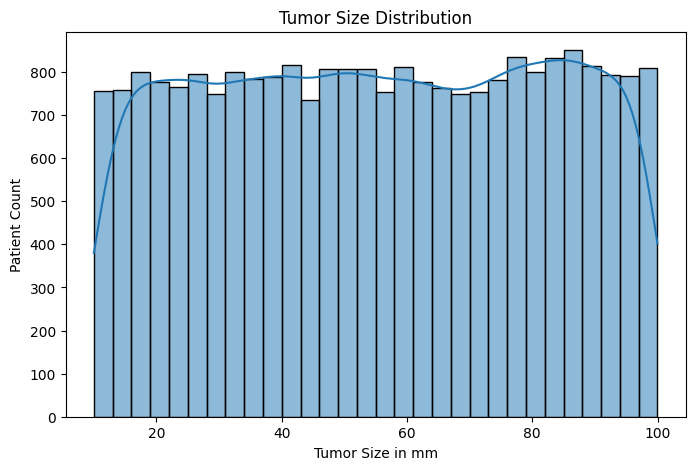

In [67]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tumor_Size_mm'], bins=30, kde=True)
plt.title('Tumor Size Distribution')
plt.xlabel('Tumor Size in mm')
plt.ylabel('Patient Count')
plt.show()

7. Cohort Analysis

In [68]:
# Stage cohort summary
stage_cohort = df.groupby('Stage').agg(
    Total_Patients=('Patient_ID', 'count'),
    Avg_Survival_Months=('Survival_Months', 'mean'),
    Avg_Tumor_Size=('Tumor_Size_mm', 'mean'),
    High_Risk_Rate=('High_Risk', 'mean')
).reset_index()

stage_cohort

,Stage,Total_Patients,Avg_Survival_Months,Avg_Tumor_Size,High_Risk_Rate
0,Stage I,5905,59.589839,55.486908,0.500593
1,Stage II,5820,59.910653,55.594976,0.488660
2,Stage III,5922,59.751604,54.888129,0.502195
3,Stage IV,6011,60.198137,55.566126,0.488438


In [69]:
# Smoking cohort summary
smoking_cohort = df.groupby('Smoking_History').agg(
    Total_Patients=('Patient_ID', 'count'),
    Avg_Survival_Months=('Survival_Months', 'mean'),
    Avg_Pack_Years=('Smoking_Pack_Years', 'mean'),
    High_Risk_Rate=('High_Risk', 'mean')
).reset_index()

smoking_cohort

,Smoking_History,Total_Patients,Avg_Survival_Months,Avg_Pack_Years,High_Risk_Rate
0,Current Smoker,7845,59.930274,49.863740,0.495347
1,Former Smoker,7998,59.749187,49.856152,0.493623
2,Never Smoked,7815,59.914395,50.022428,0.495969


In [70]:
# Treatment cohort summary
treatment_cohort = df.groupby('Treatment').agg(
    Total_Patients=('Patient_ID', 'count'),
    Avg_Survival_Months=('Survival_Months', 'mean'),
    High_Risk_Rate=('High_Risk', 'mean')
).reset_index()

treatment_cohort

,Treatment,Total_Patients,Avg_Survival_Months,High_Risk_Rate
0,Chemotherapy,5936,59.819744,0.492082
1,Radiation Therapy,5966,60.096715,0.493966
2,Surgery,5944,59.914872,0.497140
3,Targeted Therapy,5812,59.617515,0.496731


8. Prepare Data for Machine Learning

In [71]:
# Select useful columns for ML
ml_cols = [
    'Age',
    'Gender',
    'Smoking_History',
    'Tumor_Size_mm',
    'Tumor_Location',
    'Stage',
    'Treatment',
    'Ethnicity',
    'Insurance_Type',
    'Family_History',
    'Performance_Status',
    'Blood_Pressure_Systolic',
    'Blood_Pressure_Diastolic',
    'Blood_Pressure_Pulse',
    'Hemoglobin_Level',
    'White_Blood_Cell_Count',
    'Platelet_Count',
    'Albumin_Level',
    'Alkaline_Phosphatase_Level',
    'Alanine_Aminotransferase_Level',
    'Aspartate_Aminotransferase_Level',
    'Creatinine_Level',
    'LDH_Level',
    'Calcium_Level',
    'Phosphorus_Level',
    'Glucose_Level',
    'Potassium_Level',
    'Sodium_Level',
    'Smoking_Pack_Years',
    'Stage_Num',
    'Comorbidity_Count',
    'High_Risk'
]

ml_df = df[ml_cols].copy()

In [72]:
# Convert categorical columns into numbers
ml_df_encoded = pd.get_dummies(ml_df, drop_first=True)

# Separate features and target
X = ml_df_encoded.drop('High_Risk', axis=1)
y = ml_df_encoded['High_Risk']

In [73]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

9. Logistic Regression Model

In [74]:
# Build simple logistic regression model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

# Make predictions
log_pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [75]:
# Evaluate logistic regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.48732037193575656

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.60      0.54      2369
           1       0.48      0.38      0.42      2363

    accuracy                           0.49      4732
   macro avg       0.49      0.49      0.48      4732
weighted avg       0.49      0.49      0.48      4732



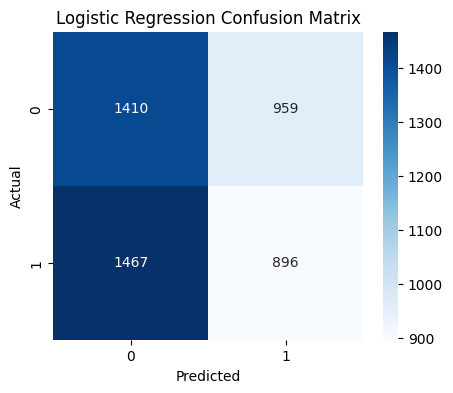

In [76]:
# Confusion matrix
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

10. Random Forest Model

In [77]:
# Build Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

In [78]:
# Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5065511411665258

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.58      0.54      2369
           1       0.51      0.43      0.47      2363

    accuracy                           0.51      4732
   macro avg       0.51      0.51      0.50      4732
weighted avg       0.51      0.51      0.50      4732



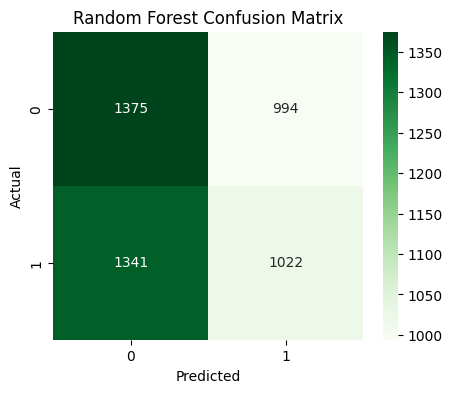

In [79]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

11. Feature Importance

In [80]:
# Get feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Show top 15 important features
importance_df.head(15)

,Feature,Importance
7,White_Blood_Cell_Count,0.044883
1,Tumor_Size_mm,0.044801
9,Albumin_Level,0.044696
14,LDH_Level,0.044351
17,Glucose_Level,0.044326
18,Potassium_Level,0.044165
10,Alkaline_Phosphatase_Level,0.044164
6,Hemoglobin_Level,0.044144
20,Smoking_Pack_Years,0.044132
12,Aspartate_Aminotransferase_Level,0.044123


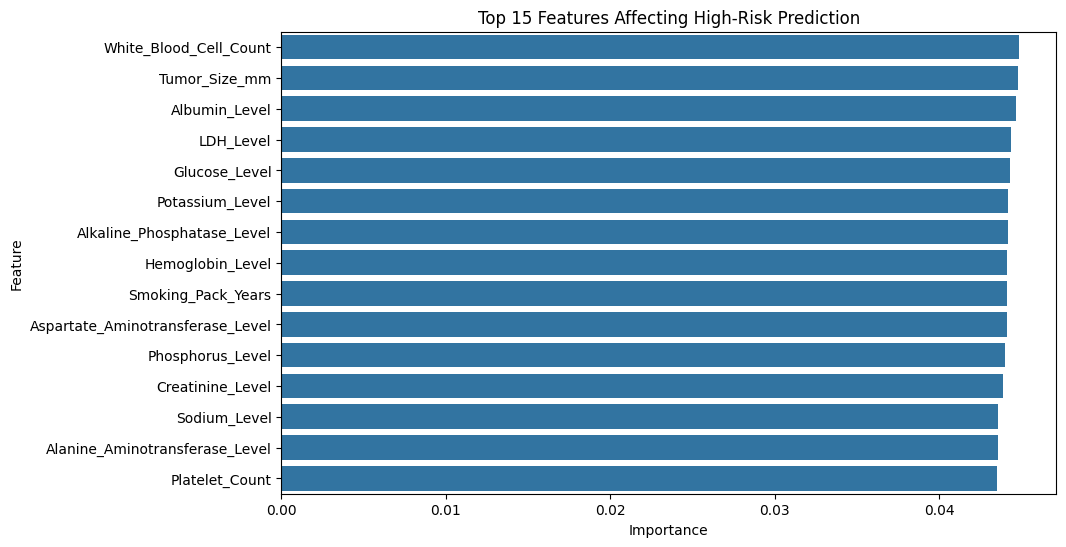

In [81]:
# Plot top 15 important features
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title('Top 15 Features Affecting High-Risk Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

12. Add Prediction Results to Original Data

In [82]:
# Predict risk for all patients
all_predictions = rf_model.predict(X)

# Predict probability of high risk
all_probabilities = rf_model.predict_proba(X)[:, 1]

# Add results to original dataframe
df['Predicted_High_Risk'] = all_predictions
df['High_Risk_Probability'] = all_probabilities

In [83]:
# Create readable risk label
df['Risk_Category'] = df['High_Risk_Probability'].apply(
    lambda x: 'High Risk' if x >= 0.60 else 'Medium Risk' if x >= 0.40 else 'Low Risk'
)

df[['Patient_ID', 'Survival_Months', 'High_Risk', 'Predicted_High_Risk', 'High_Risk_Probability', 'Risk_Category']].head()

,Patient_ID,Survival_Months,High_Risk,Predicted_High_Risk,High_Risk_Probability,Risk_Category
0,Patient0000,44,1,1,0.85,High Risk
1,Patient0001,101,0,0,0.19,Low Risk
2,Patient0002,69,0,0,0.21,Low Risk
3,Patient0003,95,0,0,0.21,Low Risk
4,Patient0004,105,0,0,0.14,Low Risk


13. Export Files for Power BI

In [84]:
# Export cleaned full dataset with ML prediction
df.to_csv("lung_cancer_patient_outcomes_powerbi.csv", index=False)

# Export cohort tables separately
stage_cohort.to_csv("stage_cohort_summary.csv", index=False)
smoking_cohort.to_csv("smoking_cohort_summary.csv", index=False)
treatment_cohort.to_csv("treatment_cohort_summary.csv", index=False)

# Export feature importance
importance_df.to_csv("feature_importance.csv", index=False)

In [85]:
from google.colab import files

files.download("lung_cancer_patient_outcomes_powerbi.csv")
files.download("stage_cohort_summary.csv")
files.download("smoking_cohort_summary.csv")
files.download("treatment_cohort_summary.csv")
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>